Dataset cargado correctamente desde: c:\Users\user\AppData\Local\GitHubDesktop\app-3.5.8\tsla-ml-project\data\processed\tsla_processed.csv
Dimensiones del dataset: (1624, 12)
Registros de entrenamiento (Train): 1299
Registros de prueba (Test): 325

--- MEJORES HIPERPARÁMETROS ENCONTRADOS ---
Ridge: {'alpha': 1.0}
Lasso: {'alpha': 1.0}
KNN: {'n_neighbors': 5, 'p': 1, 'weights': 'distance'}

--- TABLA FINAL DE EVALUACIÓN EN TEST ---
                            Modelo  MAE ($)    MSE  RMSE ($)     R²
                 Lasso (alpha=1.0)     9.67 156.42     12.51 0.9543
                    Bayesian Ridge     9.92 166.97     12.92 0.9512
           OLS (Linear Regression)     9.93 167.20     12.93 0.9511
                 Ridge (alpha=1.0)    10.02 167.81     12.95 0.9510
KNN (k=5, weights='distance', p=1)    16.57 463.73     21.53 0.8645


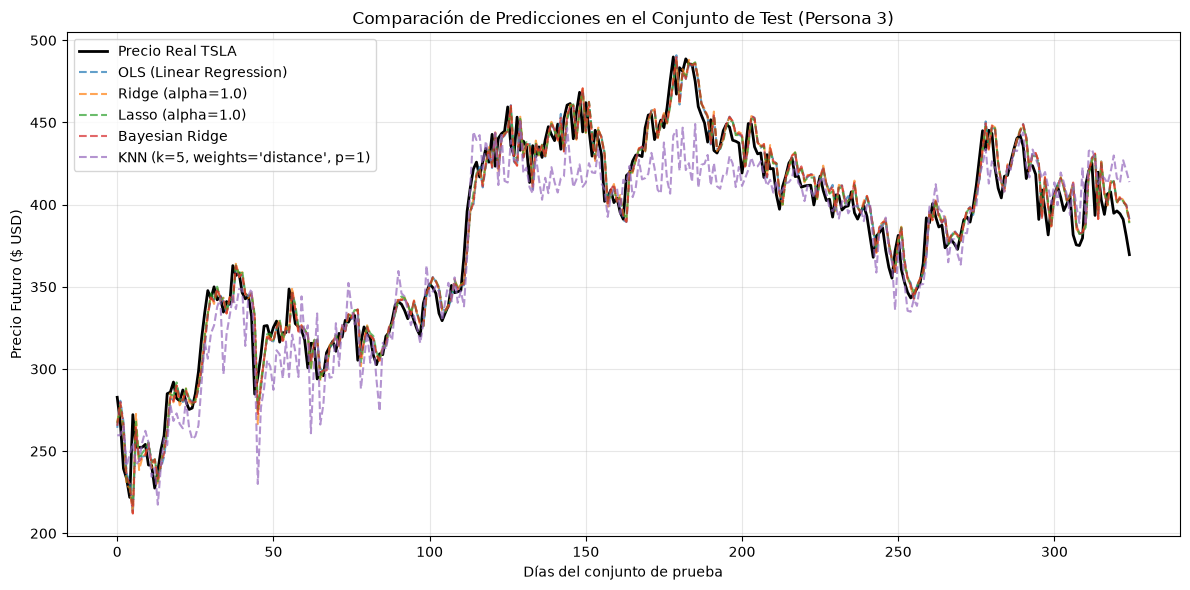

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Buscar el archivo tsla_processed.csv automáticamente en varias rutas posibles
rutas_posibles = [
    '../data/processed/tsla_processed.csv',
    '../../data/processed/tsla_processed.csv',
    'data/processed/tsla_processed.csv',
    'tsla_processed.csv'
]

ruta_encontrada = None
for ruta in rutas_posibles:
    if os.path.exists(ruta):
        ruta_encontrada = ruta
        break

if ruta_encontrada:
    df = pd.read_csv(ruta_encontrada)
    print(f"Dataset cargado correctamente desde: {os.path.abspath(ruta_encontrada)}")
    print(f"Dimensiones del dataset: {df.shape}")
else:
    raise FileNotFoundError("No se encontró 'tsla_processed.csv'. Verifica que el archivo esté en la carpeta data/processed/")

# Separar variables de entrada y variable objetivo
X = df.drop(columns=['precio_futuro'])
y = df['precio_futuro']

# Corte 80% train / 20% test manteniendo el orden temporal
split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Registros de entrenamiento (Train): {len(X_train)}")
print(f"Registros de prueba (Test): {len(X_test)}")

# Validación cruzada para series de tiempo
tscv = TimeSeriesSplit(n_splits=5)

# 1. OLS (Linear Regression)
ols = LinearRegression()
ols.fit(X_train, y_train)

# 2. Ridge Regression
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
grid_ridge = GridSearchCV(Ridge(), ridge_params, cv=tscv, scoring='neg_mean_squared_error')
grid_ridge.fit(X_train, y_train)
best_ridge = grid_ridge.best_estimator_

# 3. Lasso Regression
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
grid_lasso = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=tscv, scoring='neg_mean_squared_error')
grid_lasso.fit(X_train, y_train)
best_lasso = grid_lasso.best_estimator_

# 4. Bayesian Ridge
bayes = BayesianRidge()
bayes.fit(X_train, y_train)

# 5. KNN Regression
knn_params = {
    'n_neighbors': [3, 5, 7, 10, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
grid_knn = GridSearchCV(KNeighborsRegressor(), knn_params, cv=tscv, scoring='neg_mean_squared_error')
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_

print("\n--- MEJORES HIPERPARÁMETROS ENCONTRADOS ---")
print(f"Ridge: {grid_ridge.best_params_}")
print(f"Lasso: {grid_lasso.best_params_}")
print(f"KNN: {grid_knn.best_params_}")

# Evaluación en Test
modelos = {
    "OLS (Linear Regression)": ols,
    f"Ridge (alpha={grid_ridge.best_params_['alpha']})": best_ridge,
    f"Lasso (alpha={grid_lasso.best_params_['alpha']})": best_lasso,
    "Bayesian Ridge": bayes,
    f"KNN (k={grid_knn.best_params_['n_neighbors']}, weights='{grid_knn.best_params_['weights']}', p={grid_knn.best_params_['p']})": best_knn
}

resultados = []

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    resultados.append({
        "Modelo": nombre,
        "MAE ($)": round(mae, 2),
        "MSE": round(mse, 2),
        "RMSE ($)": round(rmse, 2),
        "R²": round(r2, 4)
    })

df_resultados = pd.DataFrame(resultados).sort_values(by="R²", ascending=False)

print("\n--- TABLA FINAL DE EVALUACIÓN EN TEST ---")
print(df_resultados.to_string(index=False))

# Gráfica comparativa
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Precio Real TSLA', color='black', linewidth=2)

for nombre, modelo in modelos.items():
    plt.plot(modelo.predict(X_test), label=nombre, alpha=0.7, linestyle='--')

plt.title('Comparación de Predicciones en el Conjunto de Test (Persona 3)')
plt.xlabel('Días del conjunto de prueba')
plt.ylabel('Precio Futuro ($ USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()